In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("../../Datasets/Travel.csv")

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [4]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [5]:
#data cleaning
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [6]:
df['MaritalStatus'].value_counts()
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [8]:
#checking for nan values 
features_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5),"%missing values")

Age 4.62357 %missing values
TypeofContact 0.51146 %missing values
DurationOfPitch 5.13502 %missing values
NumberOfFollowups 0.92062 %missing values
PreferredPropertyStar 0.53191 %missing values
NumberOfTrips 2.86416 %missing values
NumberOfChildrenVisiting 1.35025 %missing values
MonthlyIncome 4.76678 %missing values


In [9]:
#fixing nan values features
df['Age'].fillna(df['Age'].median(),inplace=True)
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0],inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0],inplace=True)
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(),inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0],inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(),inplace=True)

In [10]:
#fixing same features 
df['total_visiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],inplace=True,axis=1)
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,total_visiting
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [11]:
#extracting the differnt propertied features
num_features=[feature for feature in df.columns if df[feature].dtype!='O']
cat_features=[feature for feature in df.columns if df[feature].dtype=='O']
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
continues_features=[feature for feature in num_features if feature not in discrete_features]

In [12]:
#independent and dependent features
x=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [13]:
#train_test_Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)

In [14]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [15]:
#create a column transformer with 3 type of transformers
cat_features =x.select_dtypes(include='object').columns
num_features=x.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')
preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ])


In [16]:
x_train=pd.DataFrame(x_train,columns=x.columns)
x_train=preprocessor.fit_transform(x_train)
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.485145,-0.532978,0.290156,-0.714165,1.477805,-0.652661,0.679646,0.787648,-0.396451,-0.069993
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.485145,-1.022080,0.290156,-0.714165,-0.141499,-0.652661,0.679646,-1.269602,-0.008160,2.051504
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,-0.704079,-0.166151,0.290156,0.540275,1.477805,-0.652661,-0.054244,0.787648,0.734781,-0.777159
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.485145,-0.288426,-2.719152,-0.714165,-1.221036,-0.652661,-0.054244,0.787648,-0.727983,-1.484325
4,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.704079,-0.410702,0.290156,-0.714165,-0.141499,-0.652661,0.679646,0.787648,-0.612586,-0.069993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.704079,1.912533,0.290156,0.540275,0.398269,-0.652661,-0.054244,0.787648,0.654153,-1.484325
3906,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.704079,1.667982,-2.719152,-0.714165,-0.681268,-0.652661,-1.522024,0.787648,-1.105186,-0.777159
3907,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-0.704079,-1.022080,0.290156,-0.714165,-0.681268,-0.652661,-1.522024,-1.269602,-0.395887,-1.484325
3908,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.704079,-0.410702,0.290156,-0.714165,-0.681268,-0.652661,-1.522024,0.787648,-1.135445,-0.777159


In [17]:
#apply transformation on test(transformation)
x_test=preprocessor.transform(x_test)

AdaBoost

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error,mean_absolute_error,\
                            r2_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,ConfusionMatrixDisplay

In [19]:
models={
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Ada Boost":AdaBoostClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Logistic Regression":LogisticRegression()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)

    #make predictions
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    #training set performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

    #test set performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print('- Accuracy: {:.4f}'.format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('=====================================')

DecisionTreeClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8978
- F1 score: 0.8969
- Precision: 0.7356
- Recall: 0.7033
- Roc Auc Score: 0.8228
Gradient Boost
Model performance for Training set
- Accuracy: 0.8905
- F1 score: 0.8783
- Precision: 0.8656
- Recall: 0.4973
- Roc Auc Score: 0.7397
----------------------------------
Model performance for Test set
- Accuracy: 0.8640
- F1 score: 0.8413
- Precision: 0.8101
- Recall: 0.3516
- Roc Auc Score: 0.6664
Ada Boost
Model performance for Training set
- Accuracy: 0.8545
- F1 score: 0.8252
- Precision: 0.8189
- Recall: 0.2940
- Roc Auc Score: 0.6395
----------------------------------
Model performance for Test set
- Accuracy: 0.8466
- F1 score: 0.8089
- Precision: 0.8200
- Recall: 0.2253
- Roc Auc Score: 0.6070
Random Forest
Model performance for Training set
- Accu

In [20]:
##hyper parameter tunning 
rf_params={"max_depth":[5,8,15,None,10],
           "max_features":[5,7,"auto",8],
           "min_samples_split":[2,8,15,20],
           "n_estimators":[100,200,500,1000]
          }
adaboost_params={
    "n_estimators":[50,60,70,80,90],
    "algorithm":['SAMME','SAMME.R']
    }

In [21]:
#models list for hyperparameter tunning 
randomcv_models=[
    ("RF",RandomForestClassifier(),rf_params),
    ("AB",AdaBoostClassifier(),adaboost_params)
]

In [22]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('AB',
  AdaBoostClassifier(),
  {'n_estimators': [50, 60, 70, 80, 90], 'algorithm': ['SAMME', 'SAMME.R']})]

In [34]:
from sklearn.model_selection import RandomizedSearchCV
model_param={}
for name,model,params in randomcv_models:
    random=RandomizedSearchCV(estimator=model,
                           param_distributions=params,
                           n_iter=100, 
                           cv=3,
                           verbose=2,
                           n_jobs=-1)
    random.fit(x_train,y_train)
    model_param[name]=random.best_params_
for model_name in model_param:
    print(f"---------------Best Params for {model_name}----------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
---------------Best Params for KNN----------------------
{'n_neighbors': 3}
---------------Best Params for RF----------------------
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
---------------Best Params for AdaBoost----------------------
{'n_estimators': 70, 'loss': 'linear'}


In [35]:
models={
    "Random Forest":RandomForestClassifier(n_estimators=100,min_samples_split=2,max_features=7,max_depth=None),
    "AdaBoost":AdaBoostClassifier(n_estimators=80,algorithm='SAMME')
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)

    #make predictions
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    #training set performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

    #test set performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print('- Accuracy: {:.4f}'.format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('=====================================')

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9131
- F1 score: 0.9041
- Precision: 0.9450
- Recall: 0.5659
- Roc Auc Score: 0.7792
AdaBoost
Model performance for Training set
- Accuracy: 0.8547
- F1 score: 0.8246
- Precision: 0.8320
- Recall: 0.2886
- Roc Auc Score: 0.6375
----------------------------------
Model performance for Test set
- Accuracy: 0.8487
- F1 score: 0.8123
- Precision: 0.8269
- Recall: 0.2363
- Roc Auc Score: 0.6125


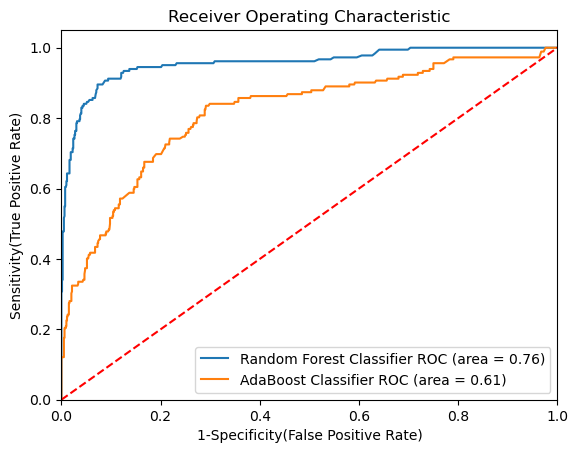

In [36]:
#plot ROC AUC Curve
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    'model': RandomForestClassifier(
                n_estimators=1000,
                min_samples_split=2,
                max_features=7,
                max_depth=None
            ),
    'auc': 0.7615
},
{
    'label': 'AdaBoost Classifier',
    'model': AdaBoostClassifier(),
    'auc': 0.6125
}
]

# create loop through all model
for algo in auc_models:
    model = algo['model']      # select the model
    model.fit(x_train, y_train)  # train the model

    # Compute False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(
        y_test,
        model.predict_proba(x_test)[:,1]
    )

    # Calculate Area under the curve to display on the plot
    plt.plot(
        fpr,
        tpr,
        label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc'])
    )

# Custom settings for the plot
plt.plot([0,1], [0,1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')

plt.savefig("auc.png")
plt.show()

In [37]:
#AdaBoost Regressor

from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np       

In [38]:
# Create a Function to Evaluate Model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [39]:
## Beginning Model Training

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Adaboost Regressor": AdaBoostRegressor()
}
for i in range(len(list(models))):

    model = list(models.values())[i]

    # Train model
    model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test,y_test_pred )

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    print('=' * 35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.3466
- Mean Absolute Error: 0.2607
- R2 Score: 0.2157
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3529
- Mean Absolute Error: 0.2615
- R2 Score: 0.1777


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.3913
- Mean Absolute Error: 0.3062
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3892
- Mean Absolute Error: 0.3046
- R2 Score: -0.0000


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.3466
- Mean Absolute Error: 0.2609
- R2 Score: 0.2154
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3529
- Mean Absolute Error: 0.2616
- R2 Score: 0.1777


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2371
- Mean Absolute Error: 0.1281
- R2 Score: 0.6330
----------------------

In [40]:
#hyperparameter tunning 
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor

In [41]:
# 1. Initialize parameter grids for Hyperparameter tuning
knn_params = {"n_neighbors": [2, 3, 10, 20, 40, 50]}

rf_params = {
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "auto", 8],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000],
}

ada_params = {
    "n_estimators": [50, 60, 70, 80],
    "loss": ["linear", "square", "exponential"],
}

In [42]:
# 2. Construct the models list containing (name, model_instance, parameter_grid)
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params),
    ("AdaBoost", AdaBoostRegressor(), ada_params),
]

In [43]:
# 3. Execute Hyperparameter Tuning
model_param = {}

for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1,
        random_state=42,  # Added for reproducibility
    )
    random.fit(x_train, y_train)
    model_param[name] = random.best_params_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [44]:
# 4. Print the optimal parameters found for each model
for model_name in model_param:
    print(
        f"------------------- Best Params for {model_name} -------------------"
    )
    print(model_param[model_name])

------------------- Best Params for KNN -------------------
{'n_neighbors': 3}
------------------- Best Params for RF -------------------
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}
------------------- Best Params for AdaBoost -------------------
{'n_estimators': 70, 'loss': 'linear'}
